<a href="https://colab.research.google.com/github/IndiraTejaswini/Pytorch_Neural_networks/blob/main/autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
from keras import layers
# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)

In the context of the autoencoder tutorial you are viewing, encoding_dim = 32 defines the size of the bottleneck or "latent space" of your neural network.

Here is why you need this specific variable:

Determining Compression Ratio: The autoencoder works by forcing data through a smaller number of neurons than the input. By setting this to 32, you are compressing the input (which is 784 pixels/floats) down to 32 floats. As noted in your code, this results in a compression factor of 24.5.

Controlling Feature Learning: The size of this layer acts as a constraint. A smaller encoding_dim forces the network to learn only the most important, high-level features of the data because it doesn't have the capacity to memorize every pixel. If this number were too large, the network might just learn to copy the input directly (identity mapping) rather than learning a useful, compressed representation.

Model Architecture: This variable is used as a parameter when defining your Keras layers, specifically telling the Dense layer how many neurons it should have:
layers.Dense(encoding_dim, activation='relu')(input_img)

encoded = layers.Dense(encoding_dim, activation='relu')(input_img):
This is your encoder. It takes the input layer (input_img) and passes it through a fully connected (Dense) layer with 32 neurons. This layer effectively "compresses" your 784-dimensional input into a 32-dimensional representation (the "bottleneck"). The relu activation function introduces the non-linearity needed for the network to learn complex patterns.

decoded = layers.Dense(784, activation='sigmoid')(encoded):
This is your decoder. It takes the 32-dimensional compressed representation (encoded) and attempts to map it back to the original input space of 784 dimensions. The sigmoid activation is used here to ensure the output values are between 0 and 1, which matches the normalized range of your input pixel data (MNIST digits).

autoencoder = keras.Model(input_img, decoded):
This line finalizes the model by linking the input directly to the output. When you train this model, it will learn to optimize the weights of both the encoder and decoder simultaneously by minimizing the difference between the input image and the reconstructed output.

In [ ]:
encoder = keras.Model(input_img, encoded)

In [ ]:
# This is our encoded (32-dimensional) input
encoded_input = keras.Input(shape=(encoding_dim,))
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

Now let's train our autoencoder to reconstruct MNIST digits.

First, we'll configure our model to use a per-pixel binary crossentropy loss, and the Adam optimizer:



In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


Let's prepare our input data. We're using MNIST digits, and we're discarding the labels (since we're only interested in encoding/decoding the input images).

In [ ]:
from keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2767 - val_loss: 0.1926
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1717 - val_loss: 0.1536
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1444 - val_loss: 0.1338
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1287 - val_loss: 0.1214
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1184 - val_loss: 0.1131
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1113 - val_loss: 0.1072
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1063 - val_loss: 0.1032
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1027 - val_loss: 0.1000
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1001 - val_loss: 0.0978
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0981 - val_loss: 0.0960
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0967 - val_loss: 0.0949
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


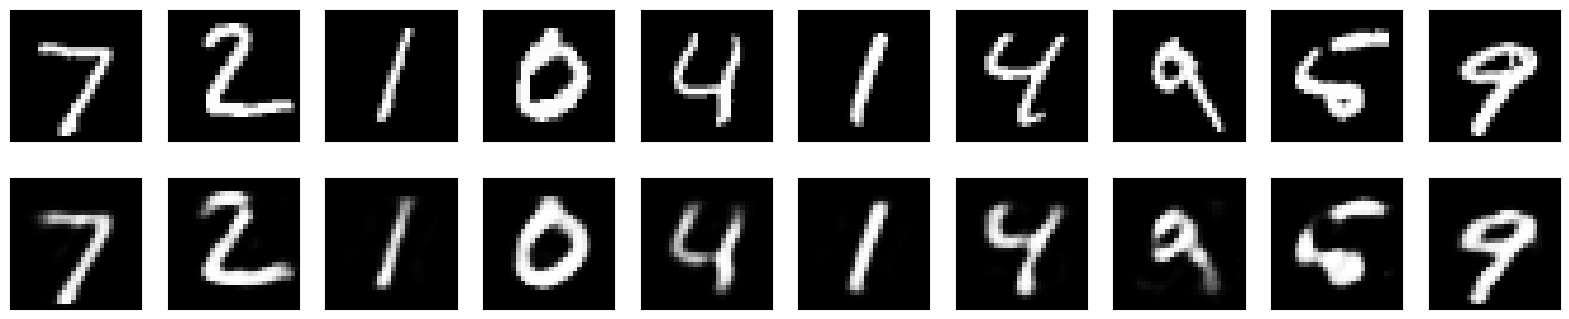

In [ ]:
import matplotlib.pyplot as plt

n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


Here's what we get. The top row is the original digits, and the bottom row is the reconstructed digits. We are losing quite a bit of detail with this basic approach.



1. What does "Sparse" mean?
In this context, an "encoded representation" is a vector of 32 numbers (the "hidden units"). Usually, many of these neurons will have non-zero, active values when processing an image.

A sparse representation is one where most of the neurons are at or near zero for any given input, and only a small subset of the neurons are "firing" (holding significant values).


3. Why would you want this?
It seems counter-intuitive to force the network to "turn off" neurons, but it is very useful for a few reasons:

Forcing "Important" Features: It acts as a filter. If a neuron only fires when it sees something very specific and meaningful (like the edge of a specific digit), it is more valuable than a neuron that fires weakly for everything. Sparsity forces the network to find the most "efficient" or "important" features to represent the data.

Preventing Overfitting: By limiting the capacity of the network (making it work harder to represent data with fewer active neurons), you prevent the network from just memorizing the training data.

Dimensionality Reduction: It creates a more "compact" representation. Even if you have 32 neurons, a sparse model might only use 5 or 6 of them at any given time, effectively compressing the information even further.

In [ ]:
from keras import regularizers

encoding_dim = 32

input_img = keras.Input(shape=(784,))
# Add a Dense layer with a L1 activity regularizer
encoded = layers.Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(10e-5))(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

**Deep autoencoder**

We do not have to limit ourselves to a single layer as encoder or decoder, we could instead use a stack of layers, such as:



In [ ]:
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

After 100 epochs, it reaches a train and validation loss of ~0.08, a bit better than our previous models. Our reconstructed digits look a bit better too:

In [ ]:
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=100,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2495 - val_loss: 0.1726
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1546 - val_loss: 0.1379
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1327 - val_loss: 0.1251
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1230 - val_loss: 0.1184
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1176 - val_loss: 0.1140
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1141 - val_loss: 0.1116
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1114 - val_loss: 0.1093
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1092 - val_loss: 0.1071
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1074 - val_loss: 0.1052
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1055 - val_loss: 0.1041
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1039 - val_loss: 0.1020
Epoch 12/100
235/235 ━━━━━━━━━

**Convolutional autoencoder**


Since our inputs are images, it makes sense to use convolutional neural networks (convnets) as encoders and decoders. In practical settings, autoencoders applied to images are always convolutional autoencoders --they simply perform much better.

Let's implement one. The encoder will consist in a stack of Conv2D and MaxPooling2D layers (max pooling being used for spatial down-sampling), while the decoder will consist in a stack of Conv2D and UpSampling2D layers.

In [ ]:
import keras
from keras import layers

input_img = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# at this point the representation is (4, 4, 8) i.e. 128-dimensional

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
from keras.datasets import mnist
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [ ]:
from keras.callbacks import TensorBoard

autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test),
                callbacks=[TensorBoard(log_dir='/tmp/autoencoder')])

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 149ms/step - loss: 0.2065 - val_loss: 0.1424
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 150ms/step - loss: 0.1337 - val_loss: 0.1251
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 151ms/step - loss: 0.1214 - val_loss: 0.1165
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 150ms/step - loss: 0.1149 - val_loss: 0.1117
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - loss: 0.1110 - val_loss: 0.1085
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 150ms/step - loss: 0.1084 - val_loss: 0.1064
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - loss: 0.1064 - val_loss: 0.1045
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 147ms/step - loss: 0.1049 - val_loss: 0.1032
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 148ms/step - loss: 0.1035 - val_loss: 0.1016
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 148ms/step - loss: 0.1024 - val_loss: 0.1006
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 151ms/step - loss: 0.1014 - val_loss: 0.0995
Epoch 12/50
469/469

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


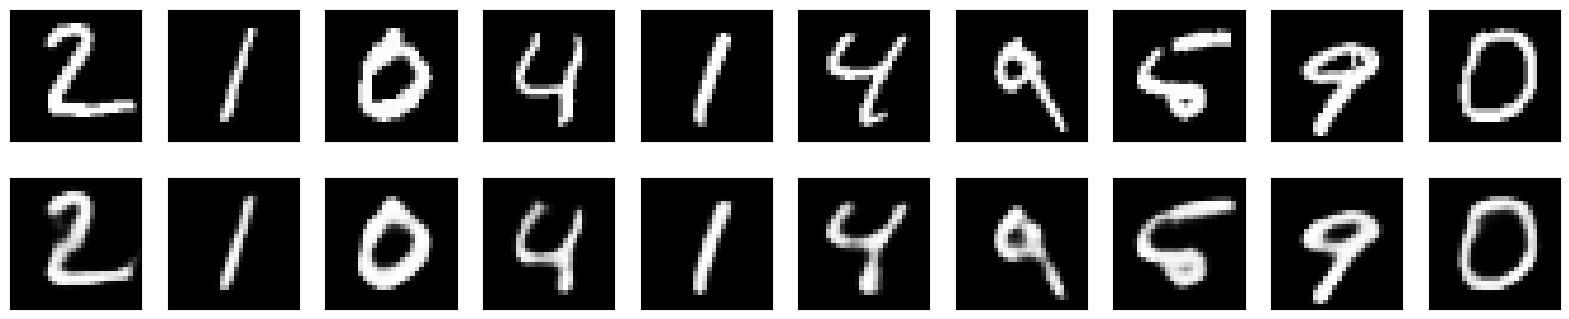

In [ ]:
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

We can also have a look at the 128-dimensional encoded representations. These representations are 8x4x4, so we reshape them to 4x32 in order to be able to display them as grayscale images.



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


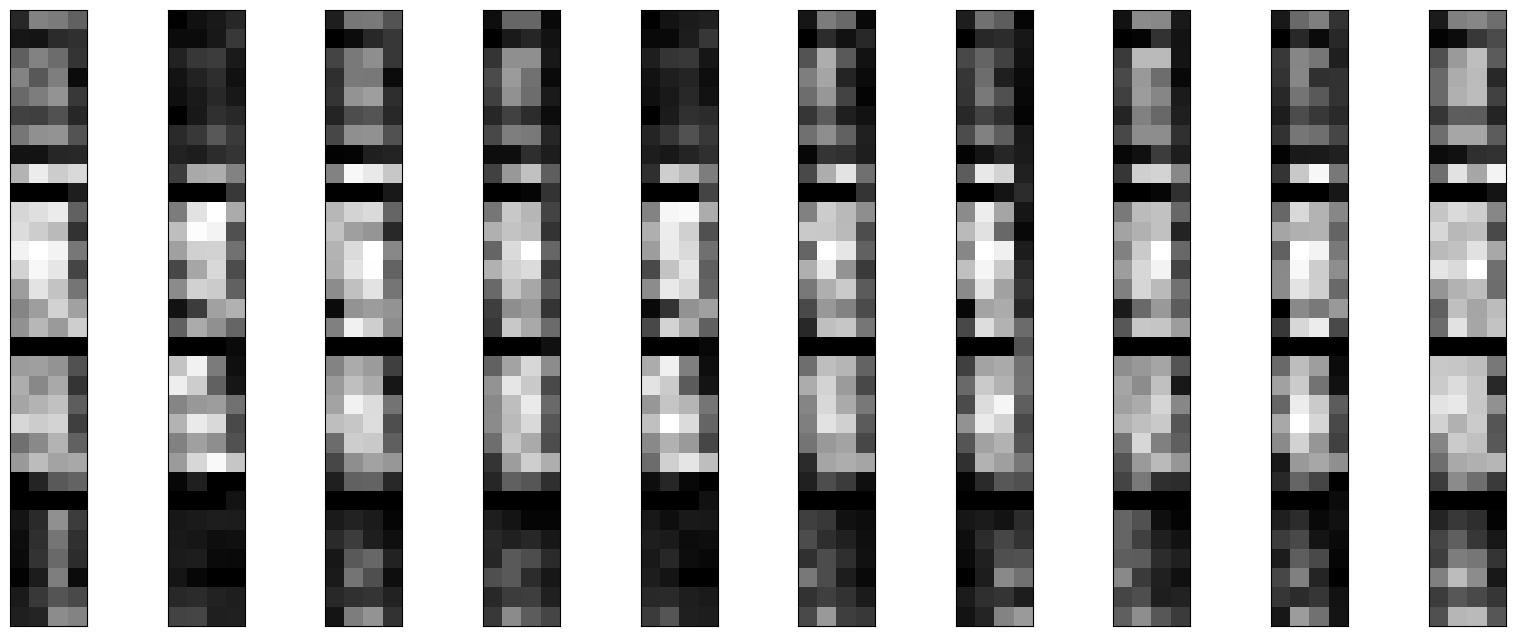

In [ ]:
encoder = keras.Model(input_img, encoded)
encoded_imgs = encoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 8))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(encoded_imgs[i].reshape((4, 4 * 8)).T)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

**Application to image denoising**


Let's put our convolutional autoencoder to work on an image denoising problem. It's simple: we will train the autoencoder to map noisy digits images to clean digits images.

Here's how we will generate synthetic noisy digits: we just apply a gaussian noise matrix and clip the images between 0 and 1.



In [ ]:
from keras.datasets import mnist
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.


Loading: You load the data. The _ underscore is used because we don't care about the labels (e.g., whether the digit is a "5" or a "2"), only the images themselves.

Normalization: You convert the pixel values (originally 0–255) to floats between 0 and 1. Neural networks converge much faster when input data is scaled this way.

In [ ]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

Standard MNIST data comes as a flat list of $28 \times 28$ images.However, Keras Conv2D layers require a 4D tensor input: (batch_size, height, width, channels). The 1 at the end indicates these are grayscale images (a single channel).

In [ ]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

This is the core of the denoising task. You are creating "noisy" versions of your images.

np.random.normal generates random Gaussian noise (static/snow).

By adding this to your clean images (x_train), you create images that are still recognizable to a human but contain pixel-level interference that the autoencoder must learn to filter out.

In [ ]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

When you add noise, some pixel values might drop below 0 or exceed 1.np.clip forces all values back into the valid $[0, 1]$ range so that the image data remains valid for the model.

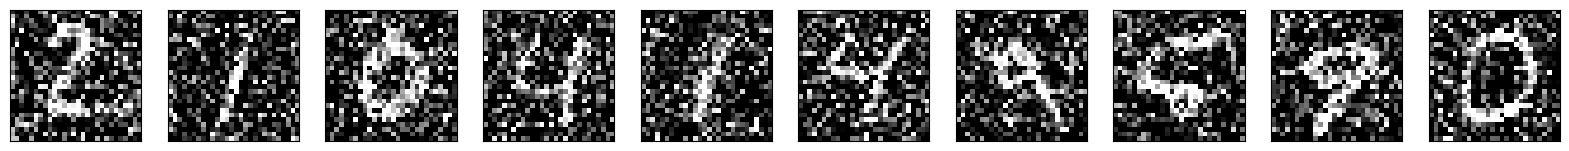

In [ ]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Compared to the previous convolutional autoencoder, in order to improve the quality of the reconstructed, we'll use a slightly different model with more filters per layer:

In [ ]:
input_img = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# At this point the representation is (7, 7, 32)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
autoencoder.fit(x_train_noisy, x_train,
                epochs=100,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test),
                callbacks=[TensorBoard(log_dir='/tmp/tb', histogram_freq=0, write_graph=False)])